# Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = "/content/drive/MyDrive/Alzheimers_Detection_dataset"
train_dir = base_path + "/train"
val_dir   = base_path + "/valid"
test_dir  = base_path + "/test"
csv_path  = base_path + "/CSV_datafiles"

print("Train folders:", os.listdir(train_dir))
print("Val folders  :", os.listdir(val_dir))
print("Test folders :", os.listdir(test_dir))
print("CSV files    :", os.listdir(csv_path))

Mounted at /content/drive
Train folders: ['VMD__1665_jpg.rf.fafb7d6e405baf878736e09e2e3038d7.jpg', 'VMD__294_jpg.rf.a7700386e5d4d7f456d8a9697b1493dd.jpg', 'VMD__1739_jpg.rf.be2e42a4af1b5dd00351d584658effe0.jpg', 'VMD__243_jpg.rf.cef78c764b9c8d98a5c9bbe6c089ad13.jpg', 'VMD__1751_jpg.rf.e0f62371e67be19d272817922a926c5b.jpg', 'VMD__1643_jpg.rf.c8ef66ff9e544c207ca99f836efbbbae.jpg', 'VMD__562_jpg.rf.ec5292fb1b39ecbf32416fff19a5f5f4.jpg', 'VMD__474_jpg.rf.a1a17cd03b02bb9a164d8fd0f9257a29.jpg', 'VMD__178_jpg.rf.ad463c957e4ea3bcf70105aa5d9247ce.jpg', 'VMD__37_jpg.rf.405c3a08f6a662ed79c1733bb250a2ba.jpg', 'VMD__2161_jpg.rf.93fcc3f3928f333e91b28bdae44d93b8.jpg', 'VMD__1834_jpg.rf.c924591e8e1ec0bfd7475cf0153e03de.jpg', 'VMD__2080_jpg.rf.8813b6e05e5366c4f871247d0ad81e86.jpg', 'VMD__28_jpg.rf.89d4cbd88e260fcbb942bf003b559139.jpg', 'VMD__302_jpg.rf.a03d17f0a08692bd64e596a9cd7311b5.jpg', 'VMD__546_jpg.rf.bdca5735ca014b55de0ced3a831e3aa2.jpg', 'VMD__187_jpg.rf.768a81c0ffb9847e3b906d685aa10f63.jpg', '

# Install Dependencies & Import Libraries

In [ ]:
!pip install opencv-python scikit-learn -q

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

IMG_SIZE    = 224
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE
CLASS_NAMES  = ['Normal', 'Mild', "Alzheimer's"]
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']
NUM_CLASSES  = 3

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load & Explore CSV Files

In [ ]:
# Load all three CSV splits
train_csv = pd.read_csv(os.path.join(csv_path, "_train_classes.csv"))
val_csv   = pd.read_csv(os.path.join(csv_path, "_valid_classes.csv"))
test_csv  = pd.read_csv(os.path.join(csv_path, "_test_classes.csv"))

print("Train CSV shape:", train_csv.shape)
print("Val   CSV shape:", val_csv.shape)
print("Test  CSV shape:", test_csv.shape)
print("\nSample rows:")
train_csv.head()

Train CSV shape: (8960, 5)
Val   CSV shape: (1280, 5)
Test  CSV shape: (640, 5)

Sample rows:


,filename,MD,MoD,ND,VMD
0,ND__2350_jpg.rf.f80ac7f889639a124e46a6161c6ead...,0,0,1,0
1,ND__2410_jpg.rf.6187777801c05a159fb8b3fbfb803f...,0,0,1,0
2,VMD__1300_jpg.rf.4d7c333b0db31734bc8aab97e1ceb...,0,0,0,1
3,VMD__1315_jpg.rf.71636662b292c60ca022a1efbc8f5...,0,0,0,1
4,ND__2408_jpg.rf.53fc1d9575791ead9974991dd8cbc4...,0,0,1,0


In [ ]:
# Class distribution from CSV
CLASS_NAMES  = ['Normal', 'Mild', "Alzheimer's"]
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']

def get_label(row):
    """Map one-hot CSV columns → integer label."""
    if row['ND'] == 1:               return 0   # Normal
    if row['VMD'] == 1 or row['MD'] == 1: return 1  # Mild
    if row['MoD'] == 1:              return 2   # Alzheimer's
    return -1

for name, df in zip(['Train', 'Val', 'Test'], [train_csv, val_csv, test_csv]):
    labels = df.apply(get_label, axis=1)
    counts = labels.value_counts().sort_index()
    print(f"{name} → Normal:{counts.get(0,0)}  Mild:{counts.get(1,0)}  Alzheimer:{counts.get(2,0)}")

Train → Normal:4444  Mild:4412  Alzheimer:88
Val → Normal:649  Mild:613  Alzheimer:15
Test → Normal:319  Mild:314  Alzheimer:5


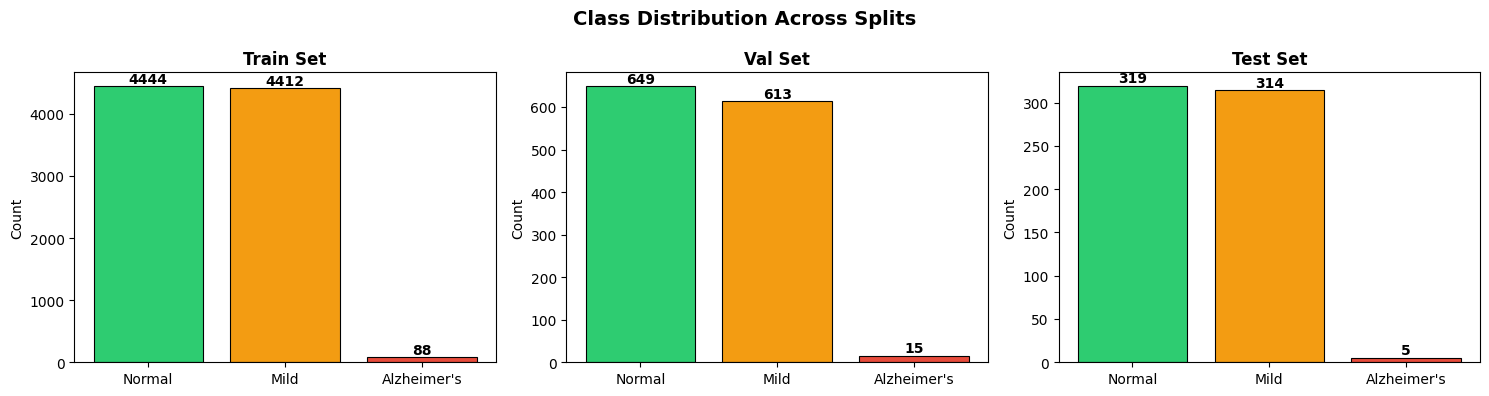

In [ ]:
# Class distribution bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, [('Train', train_csv), ('Val', val_csv), ('Test', test_csv)]):
    lbs    = df.apply(get_label, axis=1)
    counts = [lbs.value_counts().get(i, 0) for i in range(3)]
    bars   = ax.bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Digital Image Processing (DIP) Techniques
> Uses only a **small subset** of images

In [ ]:
# Load 1 sample image per class (3 images total) for DIP demos
def get_sample_images(df, img_dir, n_per_class=1):
    samples = {0: [], 1: [], 2: []}
    for _, row in df.iterrows():
        label = get_label(row)
        if label == -1 or len(samples[label]) >= n_per_class:
            continue
        path = os.path.join(img_dir, row['filename'])
        if not os.path.exists(path):
            continue
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        samples[label].append((img, label, row['filename']))
        if all(len(v) >= n_per_class for v in samples.values()):
            break
    return [item for group in samples.values() for item in group]

sample_images = get_sample_images(train_csv, train_dir, n_per_class=1)
print(f"Loaded {len(sample_images)} sample images for DIP demo")

Loaded 3 sample images for DIP demo


# Image Processing Techniques

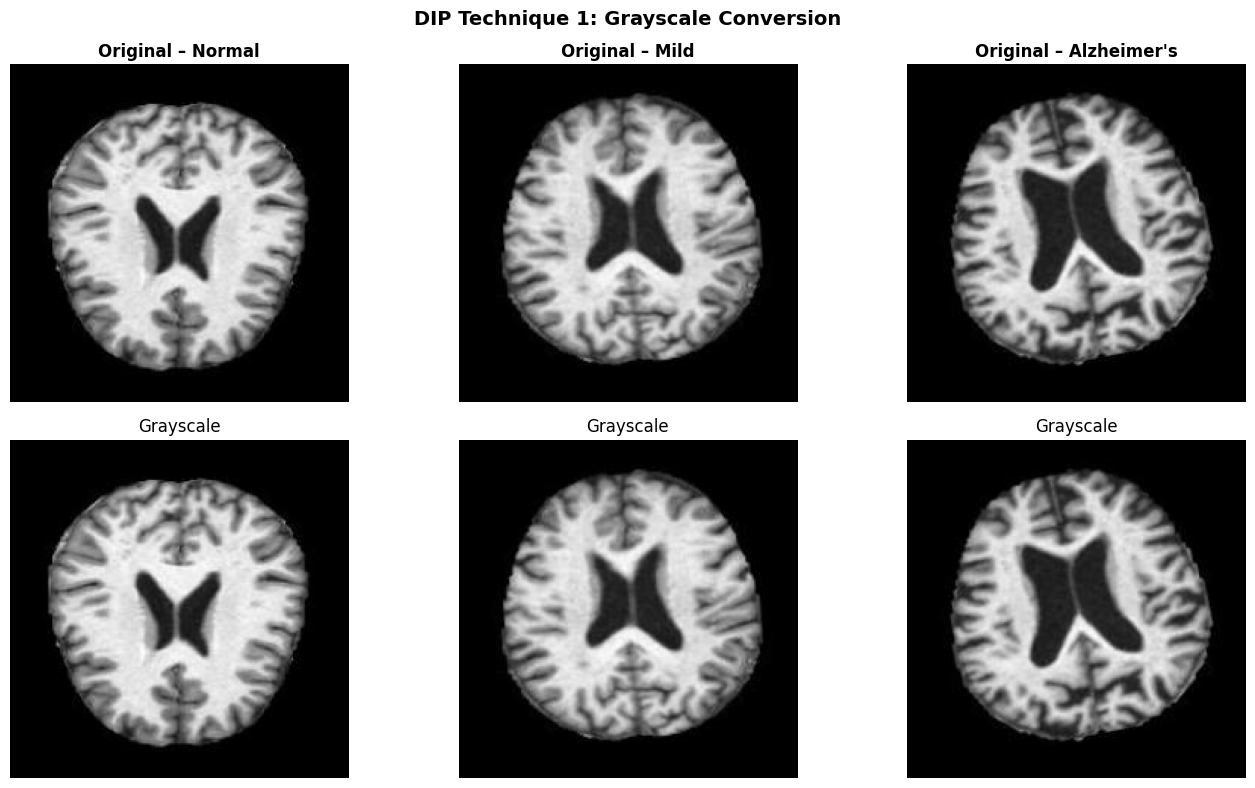

In [ ]:
# DIP TECHNIQUE 1 – Grayscale Conversion
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 1: Grayscale Conversion', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[0, idx].imshow(rgb)
    axes[0, idx].set_title(f'Original – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(gray, cmap='gray')
    axes[1, idx].set_title('Grayscale')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

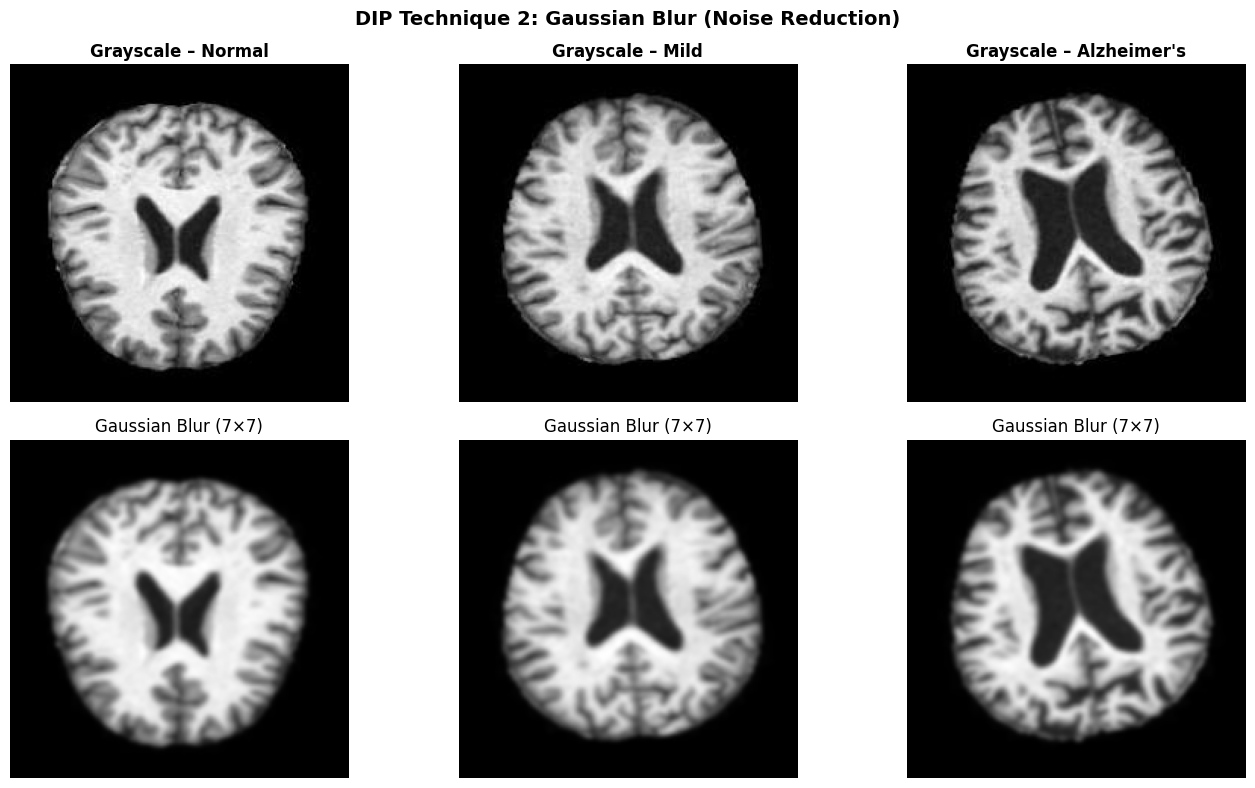

In [ ]:
# DIP TECHNIQUE 2 – Gaussian Blur
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 2: Gaussian Blur (Noise Reduction)', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Grayscale – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(blurred, cmap='gray')
    axes[1, idx].set_title('Gaussian Blur (7×7)')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

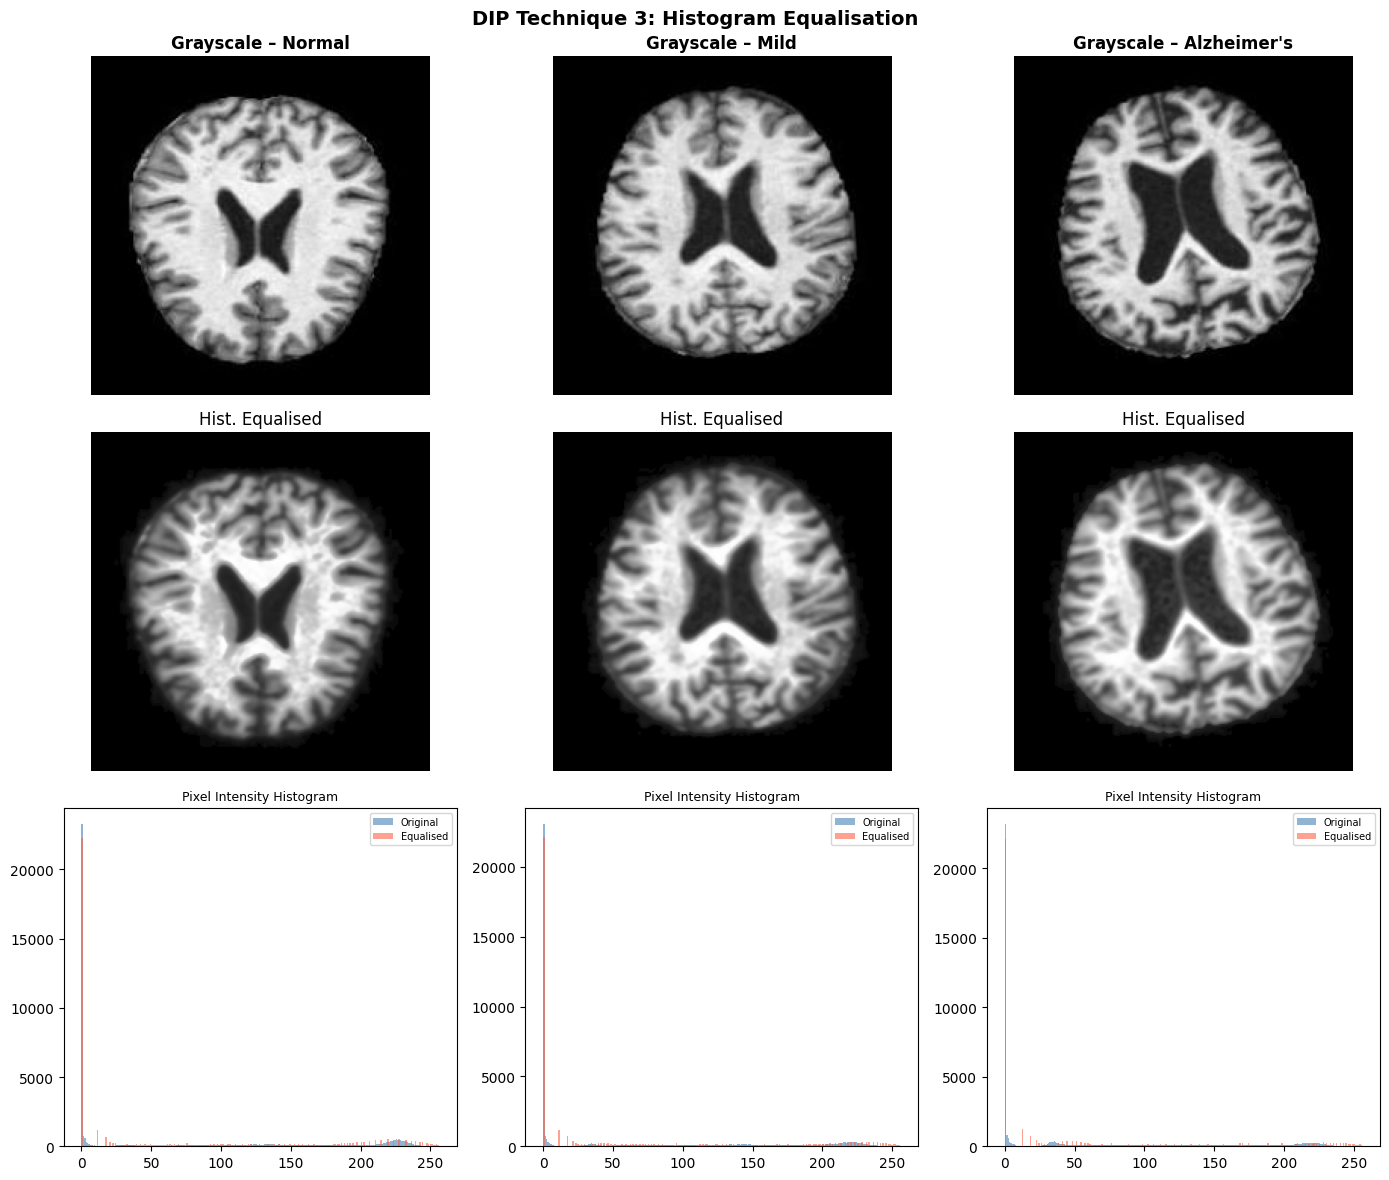

In [ ]:
# DIP TECHNIQUE 3 – Histogram Equalisation
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('DIP Technique 3: Histogram Equalisation', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    eq   = cv2.equalizeHist(blur)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Grayscale – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(eq, cmap='gray')
    axes[1, idx].set_title('Hist. Equalised')
    axes[1, idx].axis('off')
    axes[2, idx].hist(gray.ravel(), 256, [0,256], alpha=0.6, label='Original', color='steelblue')
    axes[2, idx].hist(eq.ravel(),   256, [0,256], alpha=0.6, label='Equalised', color='tomato')
    axes[2, idx].legend(fontsize=7)
    axes[2, idx].set_title('Pixel Intensity Histogram', fontsize=9)
plt.tight_layout()
plt.show()

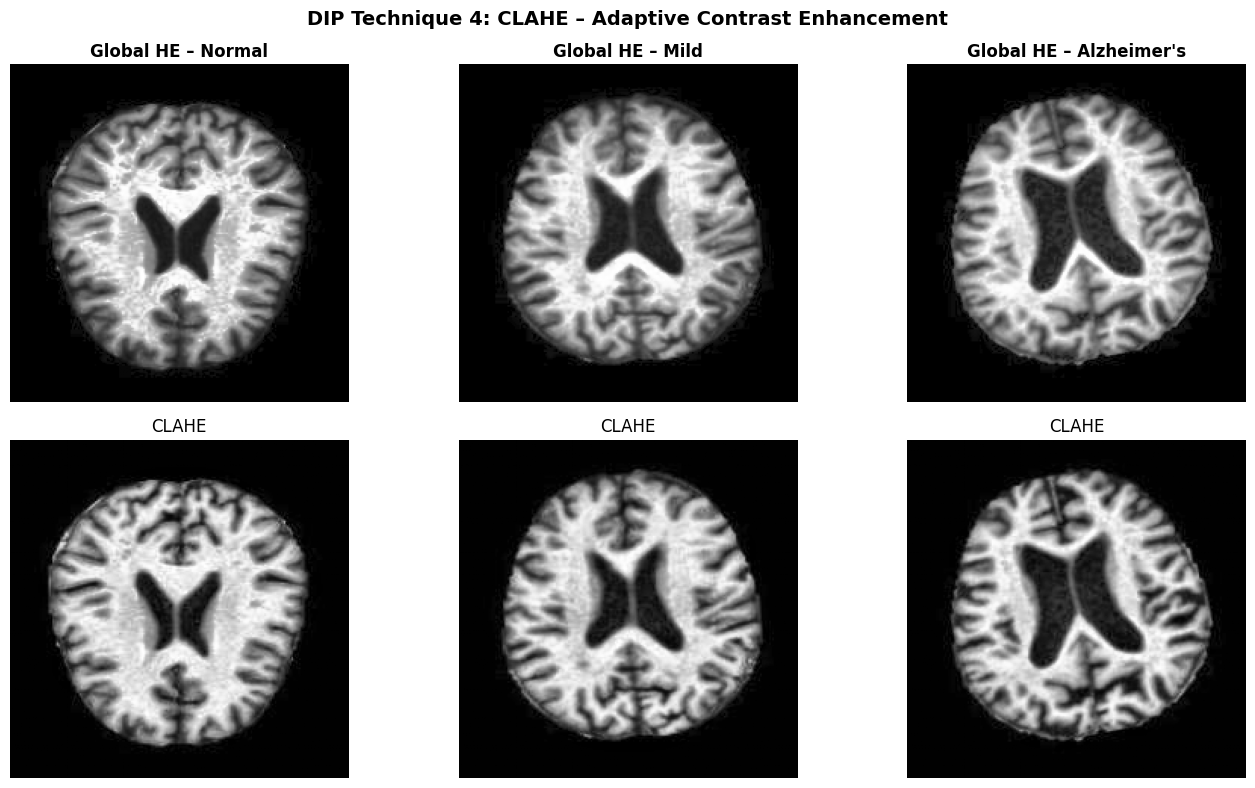

In [ ]:
# DIP TECHNIQUE 4 – CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 4: CLAHE – Adaptive Contrast Enhancement', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe_out = clahe.apply(gray)
    axes[0, idx].imshow(cv2.equalizeHist(gray), cmap='gray')
    axes[0, idx].set_title(f'Global HE – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(clahe_out, cmap='gray')
    axes[1, idx].set_title('CLAHE')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

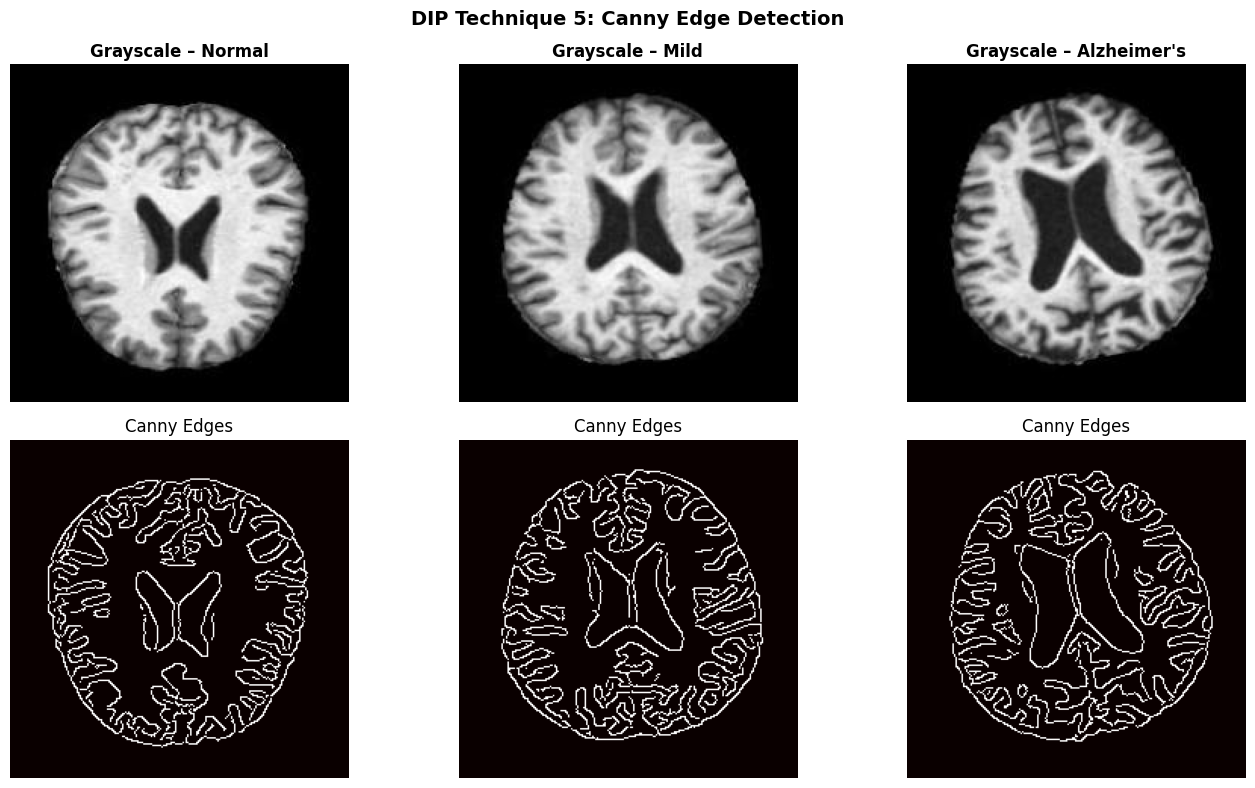

In [ ]:
# DIP TECHNIQUE 5 – Canny Edge Detection
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 5: Canny Edge Detection', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Grayscale – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(edges, cmap='hot')
    axes[1, idx].set_title('Canny Edges')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

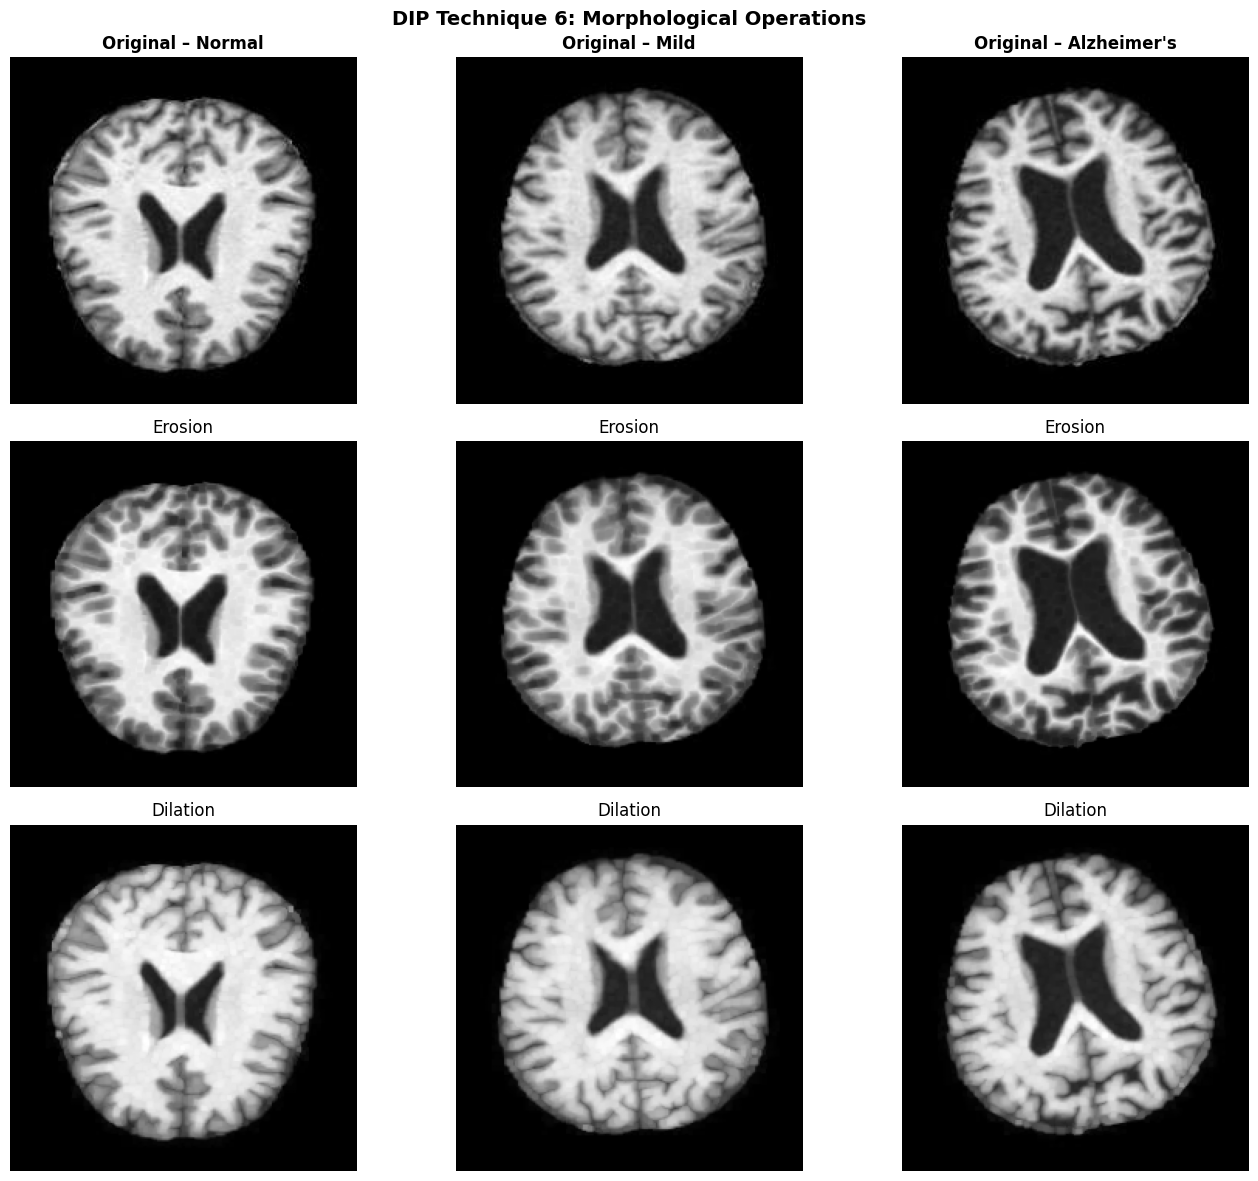

In [ ]:
# DIP TECHNIQUE 6 – Morphological Operations
kernel = np.ones((3, 3), np.uint8)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('DIP Technique 6: Morphological Operations', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    eroded  = cv2.erode(gray,  kernel, iterations=1)
    dilated = cv2.dilate(gray, kernel, iterations=1)
    axes[0, idx].imshow(gray,    cmap='gray')
    axes[0, idx].set_title(f'Original – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(eroded,  cmap='gray')
    axes[1, idx].set_title('Erosion')
    axes[1, idx].axis('off')
    axes[2, idx].imshow(dilated, cmap='gray')
    axes[2, idx].set_title('Dilation')
    axes[2, idx].axis('off')
plt.tight_layout()
plt.show()

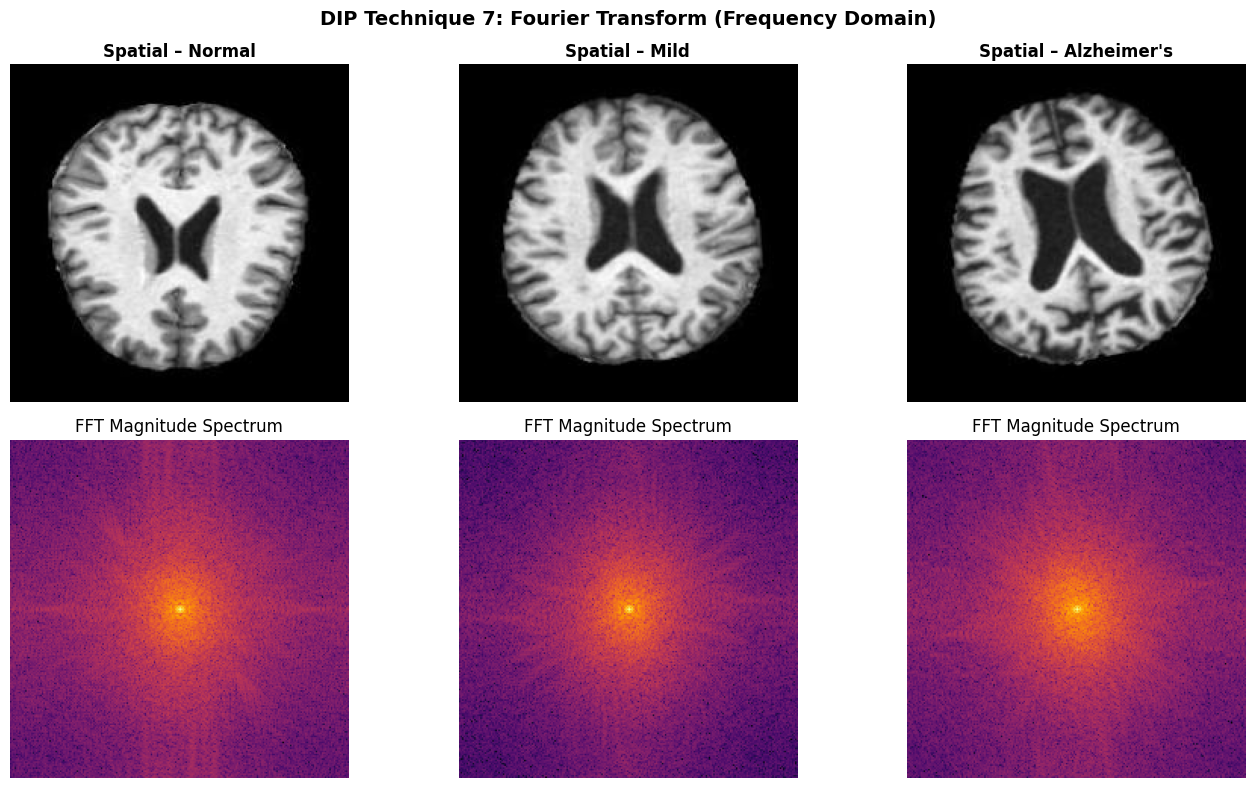

In [ ]:
# DIP TECHNIQUE 7 – Fourier Transform
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 7: Fourier Transform (Frequency Domain)', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    mag    = 20 * np.log(np.abs(fshift) + 1)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Spatial – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(mag, cmap='inferno')
    axes[1, idx].set_title('FFT Magnitude Spectrum')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

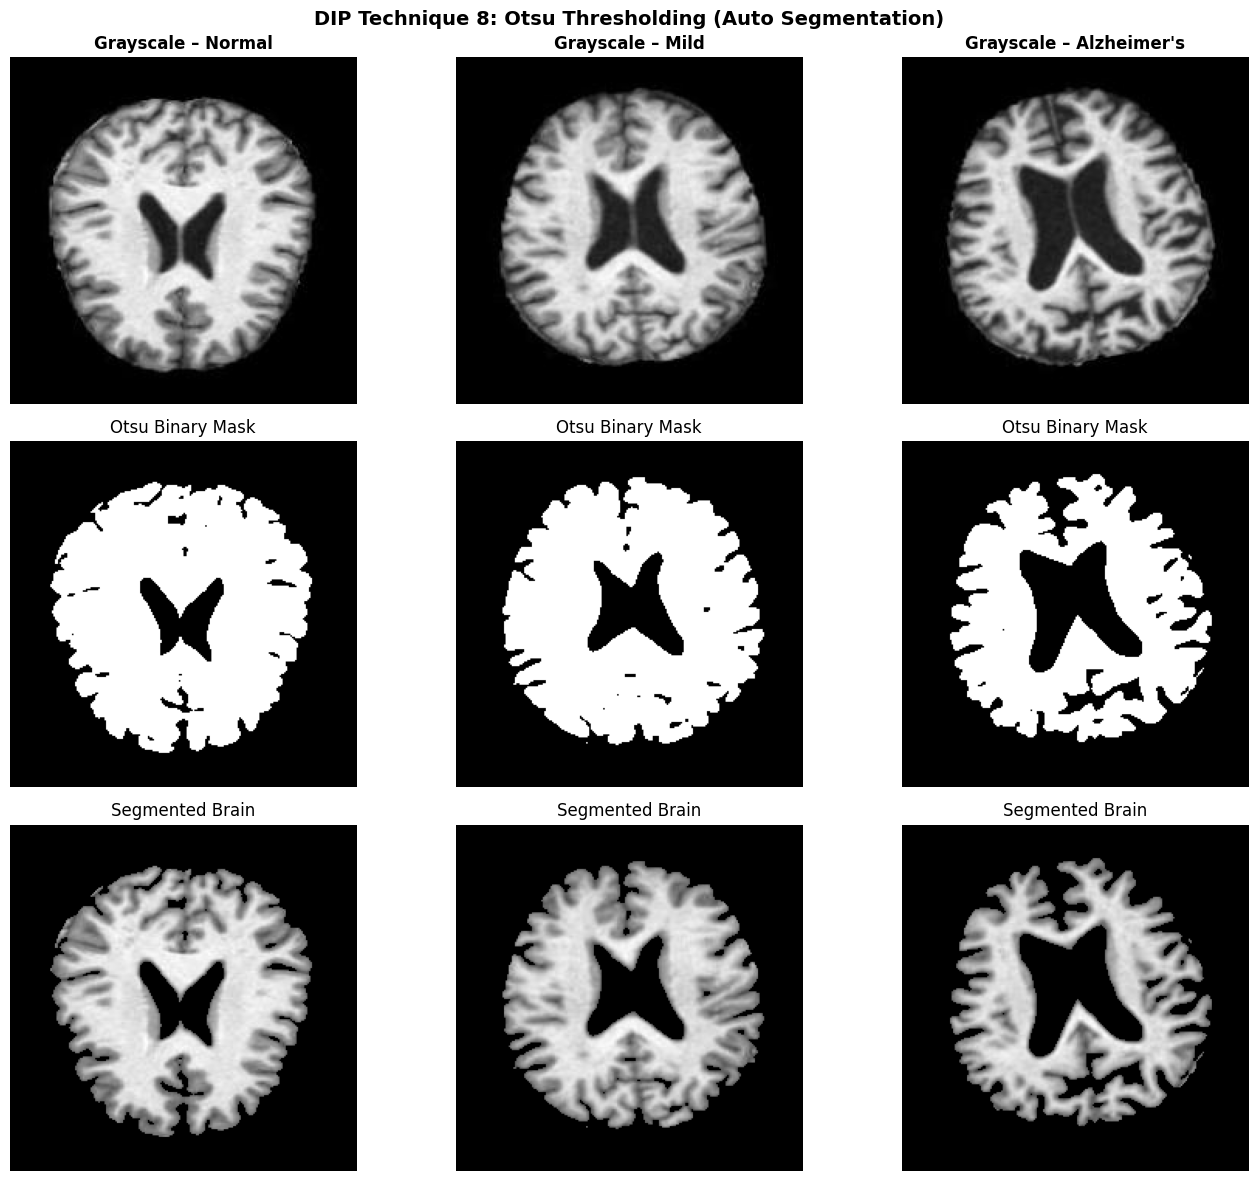

In [ ]:
# DIP TECHNIQUE 8 – Otsu Thresholding
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('DIP Technique 8: Otsu Thresholding (Auto Segmentation)', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    seg     = cv2.bitwise_and(gray, gray, mask=mask)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Grayscale – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title('Otsu Binary Mask')
    axes[1, idx].axis('off')
    axes[2, idx].imshow(seg, cmap='gray')
    axes[2, idx].set_title('Segmented Brain')
    axes[2, idx].axis('off')
plt.tight_layout()
plt.show()

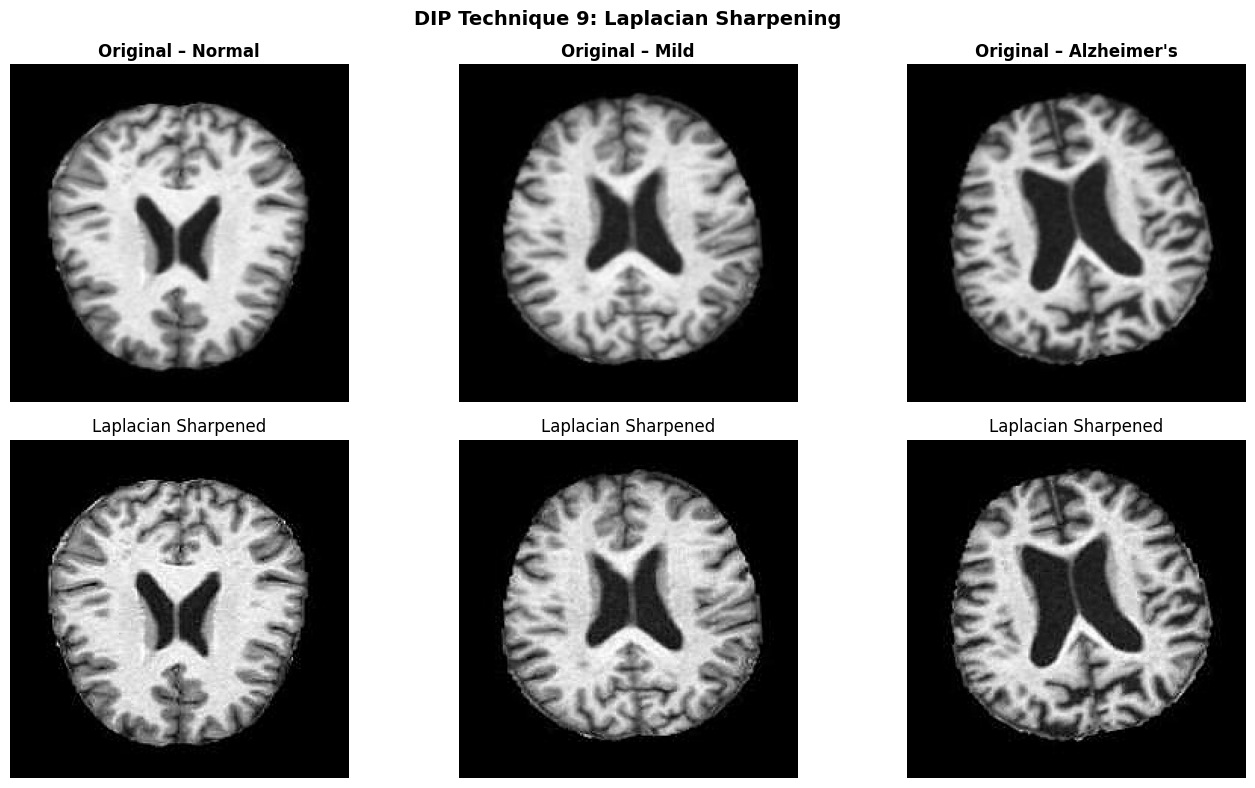

In [ ]:
# DIP TECHNIQUE 9 – Laplacian Sharpening
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('DIP Technique 9: Laplacian Sharpening', fontsize=14, fontweight='bold')
for idx, (img_bgr, label, _) in enumerate(sample_images):
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lap       = cv2.Laplacian(gray, cv2.CV_64F)
    sharpened = np.clip(gray.astype(float) - 0.5 * lap, 0, 255).astype(np.uint8)
    axes[0, idx].imshow(gray, cmap='gray')
    axes[0, idx].set_title(f'Original – {CLASS_NAMES[label]}', fontweight='bold')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(sharpened, cmap='gray')
    axes[1, idx].set_title('Laplacian Sharpened')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()

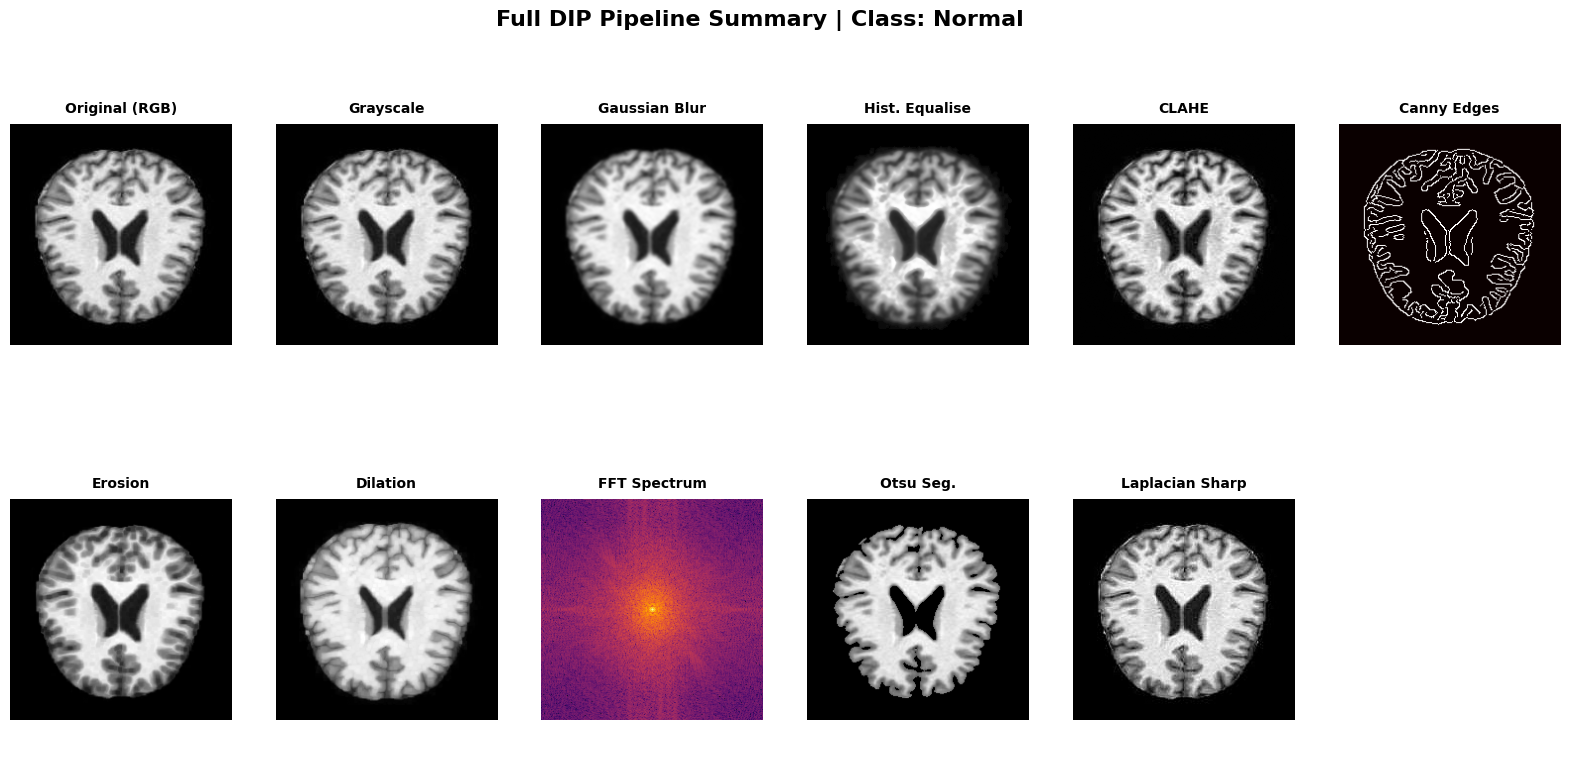

In [ ]:
# FULL DIP PIPELINE SUMMARY – all 9 steps on one image
img_bgr, label, _ = sample_images[0]
gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur    = cv2.GaussianBlur(gray, (5, 5), 0)
eq      = cv2.equalizeHist(blur)
cl_out  = clahe.apply(gray)
edges   = cv2.Canny(blur, 50, 150)
eroded  = cv2.erode(gray,  kernel, iterations=1)
dilated = cv2.dilate(gray, kernel, iterations=1)
mag     = 20 * np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray))) + 1)
_, msk  = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
seg     = cv2.bitwise_and(gray, gray, mask=msk)
lap     = cv2.Laplacian(gray, cv2.CV_64F)
sharp   = np.clip(gray.astype(float) - 0.5*lap, 0, 255).astype(np.uint8)

steps  = [cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
          gray, blur, eq, cl_out, edges, eroded, dilated, mag, seg, sharp]
titles = ['Original (RGB)', 'Grayscale', 'Gaussian Blur', 'Hist. Equalise',
          'CLAHE', 'Canny Edges', 'Erosion', 'Dilation',
          'FFT Spectrum', 'Otsu Seg.', 'Laplacian Sharp']
cmaps  = [None,'gray','gray','gray','gray','hot','gray','gray','inferno','gray','gray']

fig, axes = plt.subplots(2, 6, figsize=(20, 8))
axes = axes.flatten()

fig.suptitle(f'Full DIP Pipeline Summary | Class: {CLASS_NAMES[label]}',
             fontsize=16, fontweight='bold', y=0.98)

for i in range(len(steps)):
    axes[i].imshow(steps[i], cmap=cmaps[i])
    axes[i].set_title(titles[i], fontsize=10, fontweight='bold', pad=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.subplots_adjust(top=0.88, bottom=0.05, hspace=0.3, wspace=0.2)
plt.show()

  Found 638 valid samples (rebuilt within visualize_class_pipeline cell)


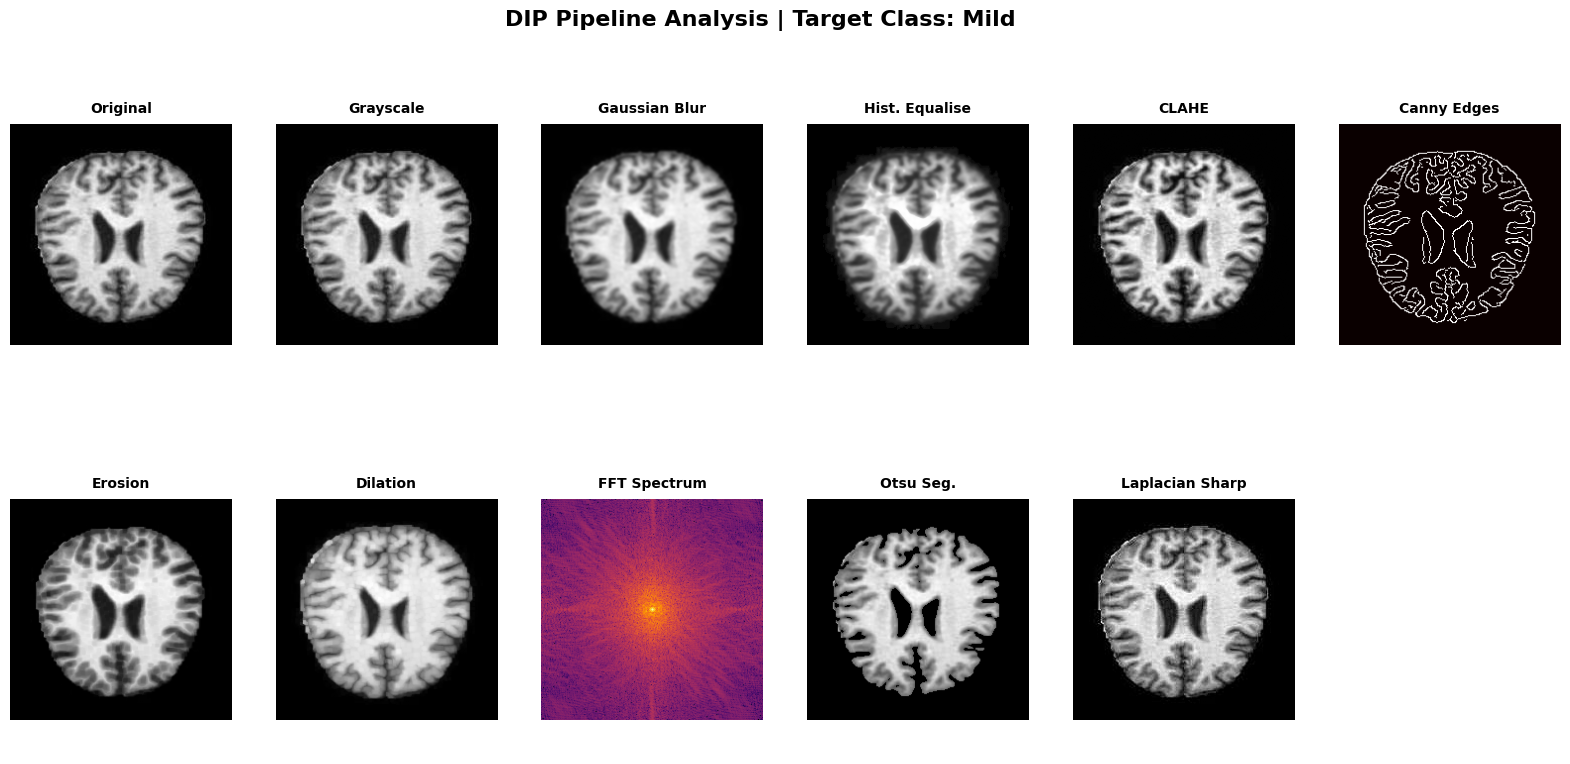

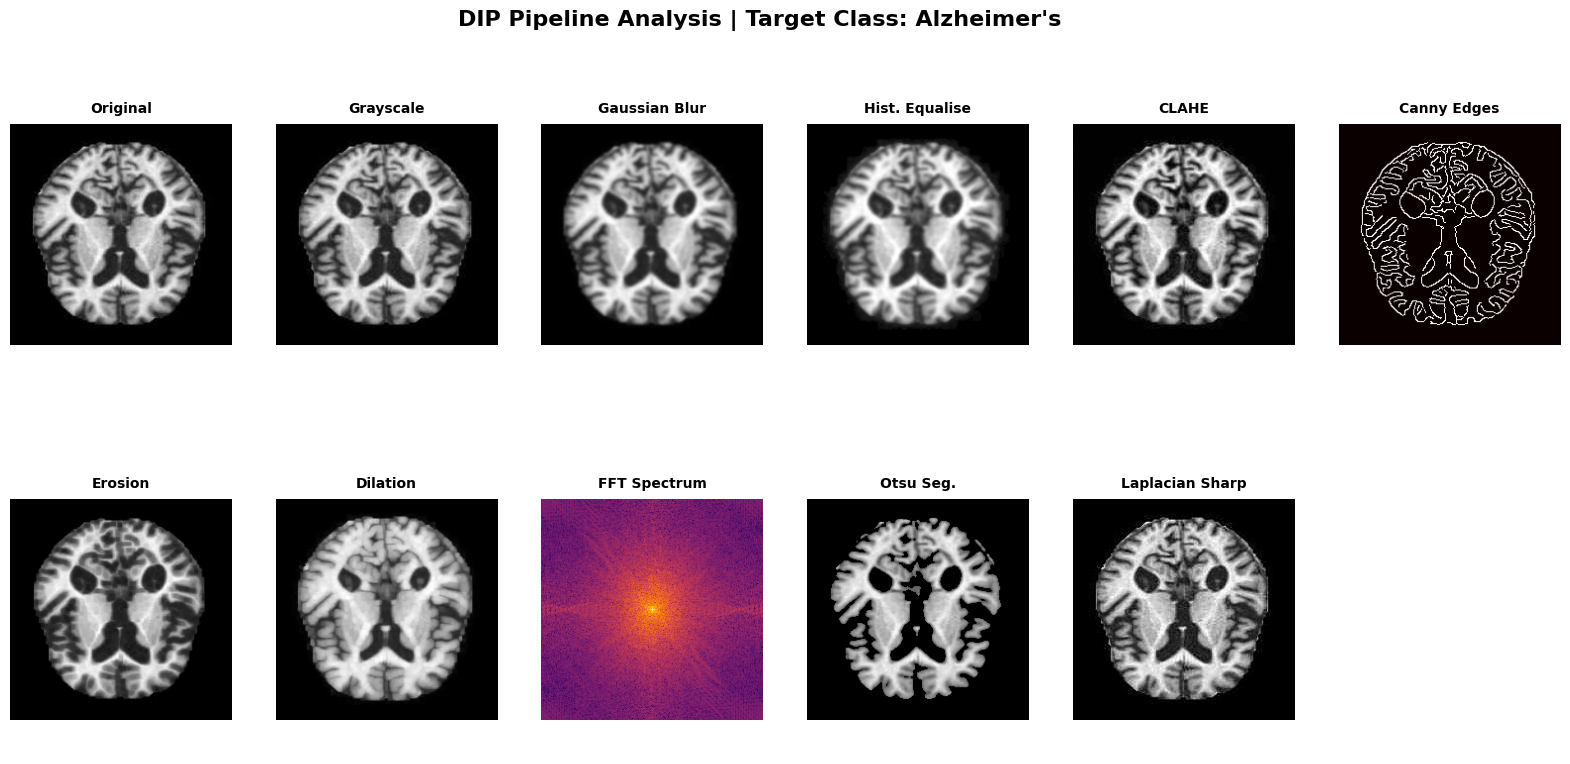

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os # Added os import for build_paths_and_labels

def build_paths_and_labels(df, img_dir):
    """Extract (path, integer_label) pairs from CSV — tiny memory footprint."""
    paths, labels = [], []
    for _, row in df.iterrows():
        label = get_label(row)
        if label == -1:
            continue
        path = os.path.join(img_dir, row['filename'])
        if not os.path.exists(path):
            continue
        paths.append(path)
        labels.append(label)
    print(f"  Found {len(paths)} valid samples (rebuilt within visualize_class_pipeline cell)")
    return paths, labels

if 'test_paths' not in globals() or 'test_labels' not in globals():
    print("Warning: 'test_paths' or 'test_labels' not found in global scope. Rebuilding them for this cell.")
    test_paths, test_labels = build_paths_and_labels(test_csv, test_dir)

def visualize_class_pipeline(class_idx):
    # Find the first image belonging to the requested class
    sample_img_path = None
    for path, label in zip(test_paths, test_labels):
        if label == class_idx:
            sample_img_path = path
            break

    if not sample_img_path:
        print(f"No samples found for class {CLASS_NAMES[class_idx]}")
        return

    # Load and Preprocess
    img_bgr = cv2.imread(sample_img_path)
    img_bgr = cv2.resize(img_bgr, (224, 224))
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)

    # DIP Steps
    eq      = cv2.equalizeHist(blur)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl_out  = clahe.apply(gray)
    edges   = cv2.Canny(blur, 50, 150)
    kernel  = np.ones((3,3), np.uint8)
    eroded  = cv2.erode(gray, kernel, iterations=1)
    dilated = cv2.dilate(gray, kernel, iterations=1)

    # Frequency Domain (FFT)
    f_shift = np.fft.fftshift(np.fft.fft2(gray))
    mag     = 20 * np.log(np.abs(f_shift) + 1)

    # Segmentation & Sharpening
    _, msk  = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    seg     = cv2.bitwise_and(gray, gray, mask=msk)
    lap     = cv2.Laplacian(gray, cv2.CV_64F)
    sharp   = np.clip(gray.astype(float) - 0.5*lap, 0, 255).astype(np.uint8)

    steps  = [cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), gray, blur, eq, cl_out,
              edges, eroded, dilated, mag, seg, sharp]
    titles = ['Original', 'Grayscale', 'Gaussian Blur', 'Hist. Equalise', 'CLAHE',
              'Canny Edges', 'Erosion', 'Dilation', 'FFT Spectrum', 'Otsu Seg.', 'Laplacian Sharp']
    cmaps  = [None,'gray','gray','gray','gray','hot','gray','gray','inferno','gray','gray']

    # Plotting
    fig, axes = plt.subplots(2, 6, figsize=(20, 8))
    axes = axes.flatten()
    fig.suptitle(f'DIP Pipeline Analysis | Target Class: {CLASS_NAMES[class_idx]}',
                 fontsize=16, fontweight='bold', y=0.98)

    for i in range(len(steps)):
        axes[i].imshow(steps[i], cmap=cmaps[i])
        axes[i].set_title(titles[i], fontsize=10, fontweight='bold', pad=8)
        axes[i].axis('off')

    # Hide unused 12th subplot
    axes[-1].axis('off')

    plt.subplots_adjust(top=0.88, bottom=0.05, hspace=0.3, wspace=0.2)
    plt.show()

# Run for Mild (index 1) and Alzheimer's (index 2)
visualize_class_pipeline(1)
visualize_class_pipeline(2)

## Memory-Efficient tf.data Pipeline
> Images are loaded **32 at a time** — no large numpy arrays in RAM

In [ ]:
def preprocess_image_tf(img_path):
    """TF-native preprocessing: resize + histogram-equalise equivalent + normalise."""
    raw  = tf.io.read_file(img_path)
    img  = tf.image.decode_jpeg(raw, channels=3)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32) / 255.0
    return img


def build_paths_and_labels(df, img_dir):
    """Extract (path, integer_label) pairs from CSV — tiny memory footprint."""
    paths, labels = [], []
    for _, row in df.iterrows():
        label = get_label(row)
        if label == -1:
            continue
        path = os.path.join(img_dir, row['filename'])
        if not os.path.exists(path):
            continue
        paths.append(path)
        labels.append(label)
    print(f"  Found {len(paths)} valid samples")
    return paths, labels


def make_dataset(paths, labels, augment=False, shuffle=False):
    """Build a batched, prefetched tf.data.Dataset with one-hot labels."""
    labels_oh = to_categorical(labels, num_classes=NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_oh))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)

    def load_fn(path, label):
        return preprocess_image_tf(path), label

    ds = ds.map(load_fn, num_parallel_calls=AUTOTUNE)

    if augment:
        def augment_fn(img, label):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)
            img = tf.clip_by_value(img, 0.0, 1.0)
            return img, label
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# Build path lists
print("Building Train...")
train_paths, train_labels = build_paths_and_labels(train_csv, train_dir)
print("Building Val...")
val_paths,   val_labels   = build_paths_and_labels(val_csv,   val_dir)
print("Building Test...")
test_paths,  test_labels  = build_paths_and_labels(test_csv,  test_dir)

# Build tf.data datasets
train_ds = make_dataset(train_paths, train_labels, augment=True,  shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   augment=False, shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  augment=False, shuffle=False)

print("\nDatasets ready — images load per batch")

Building Train...
  Found 8944 valid samples
Building Val...
  Found 1277 valid samples
Building Test...
  Found 638 valid samples

Datasets ready — images load per batch


## Build CNN Model (ResNet50 Transfer Learning)

In [ ]:
def build_model(num_classes=NUM_CLASSES, fine_tune_from=140):
    """ResNet50 backbone with partial fine-tuning + custom classification head."""
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Freeze all backbone layers
    for layer in base.layers:
        layer.trainable = False

    # Unfreeze top layers for fine-tuning
    for layer in base.layers[fine_tune_from:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=base.input, outputs=out)


model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
total     = sum(np.prod(v.shape) for v in model.weights)
print(f"\nTrainable params : {trainable:,}")
print(f"Total params     : {total:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,153,731 (92.14 MB)

 Trainable params: 15,539,971 (59.28 MB)

 Non-trainable params: 8,613,760 (32.86 MB)


Trainable params : 15,539,971
Total params     : 24,153,731


## Train the Model

In [ ]:
# Class weights
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(cw))
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

# Callbacks
cb_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_alzheimer_model.h5',
                               monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

# Train
history = model.fit(
    train_ds,                    # ← tf.data, loads 32 images at a time
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=cb_list,
    verbose=1
)

Class weights: {'Normal': np.float64(0.671), 'Mild': np.float64(0.676), "Alzheimer's": np.float64(33.879)}
Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4926 - loss: 1.4215 
Epoch 1: val_accuracy improved from None to 0.50822, saving model to best_alzheimer_model.h5



Epoch 1: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 3689s 13s/step - accuracy: 0.4795 - loss: 1.2896 - val_accuracy: 0.5082 - val_loss: 0.8937 - learning_rate: 1.0000e-04
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5289 - loss: 0.9201
Epoch 2: val_accuracy did not improve from 0.50822
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 150ms/step - accuracy: 0.5310 - loss: 0.9556 - val_accuracy: 0.4244 - val_loss: 1.2983 - learning_rate: 1.0000e-04
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5267 - loss: 0.8997
Epoch 3: val_accuracy improved from 0.50822 to 0.62960, saving model to best_alzheimer_model.h5



Epoch 3: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 152ms/step - accuracy: 0.5428 - loss: 0.8657 - val_accuracy: 0.6296 - val_loss: 0.8069 - learning_rate: 1.0000e-04
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5696 - loss: 0.8582
Epoch 4: val_accuracy did not improve from 0.62960
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 146ms/step - accuracy: 0.5685 - loss: 0.8418 - val_accuracy: 0.5215 - val_loss: 1.3254 - learning_rate: 1.0000e-04
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5925 - loss: 0.7410
Epoch 5: val_accuracy improved from 0.62960 to 0.66562, saving model to best_alzheimer_model.h5



Epoch 5: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.5956 - loss: 0.7429 - val_accuracy: 0.6656 - val_loss: 0.7403 - learning_rate: 1.0000e-04
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6025 - loss: 0.6827
Epoch 6: val_accuracy improved from 0.66562 to 0.68050, saving model to best_alzheimer_model.h5



Epoch 6: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 152ms/step - accuracy: 0.6073 - loss: 0.7045 - val_accuracy: 0.6805 - val_loss: 0.9163 - learning_rate: 1.0000e-04
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6301 - loss: 0.6446
Epoch 7: val_accuracy improved from 0.68050 to 0.70713, saving model to best_alzheimer_model.h5



Epoch 7: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.6278 - loss: 0.6504 - val_accuracy: 0.7071 - val_loss: 0.6810 - learning_rate: 1.0000e-04
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6327 - loss: 0.6819
Epoch 8: val_accuracy did not improve from 0.70713
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 148ms/step - accuracy: 0.6390 - loss: 0.6389 - val_accuracy: 0.1825 - val_loss: 2.7048 - learning_rate: 1.0000e-04
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6335 - loss: 0.6267
Epoch 9: val_accuracy improved from 0.70713 to 0.71182, saving model to best_alzheimer_model.h5



Epoch 9: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 153ms/step - accuracy: 0.6426 - loss: 0.6161 - val_accuracy: 0.7118 - val_loss: 0.7823 - learning_rate: 1.0000e-04
Epoch 10/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6637 - loss: 0.5853
Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 10: val_accuracy did not improve from 0.71182
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 150ms/step - accuracy: 0.6587 - loss: 0.6067 - val_accuracy: 0.5521 - val_loss: 1.0245 - learning_rate: 1.0000e-04
Epoch 11/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6687 - loss: 0.5678
Epoch 11: val_accuracy did not improve from 0.71182
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 148ms/step - accuracy: 0.6718 - loss: 0.5578 - val_accuracy: 0.6554 - val_loss: 0.7088 - learning_rate: 5.0000e-05
Epoch 12/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6747 - loss: 0.5374
Epoch 12: val_accuracy did not improve from 0.71


Epoch 14: finished saving model to best_alzheimer_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 151ms/step - accuracy: 0.6903 - loss: 0.5121 - val_accuracy: 0.7729 - val_loss: 0.5639 - learning_rate: 2.5000e-05
Epoch 15/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7107 - loss: 0.4769
Epoch 15: val_accuracy did not improve from 0.77291
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.7093 - loss: 0.4805 - val_accuracy: 0.7142 - val_loss: 0.6385 - learning_rate: 2.5000e-05
Epoch 16/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7137 - loss: 0.4721
Epoch 16: val_accuracy did not improve from 0.77291
280/280 ━━━━━━━━━━━━━━━━━━━━ 81s 147ms/step - accuracy: 0.7185 - loss: 0.4676 - val_accuracy: 0.6922 - val_loss: 0.6639 - learning_rate: 2.5000e-05
Epoch 17/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7184 - loss: 0.4829
Epoch 17: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 17: val_accuracy did not improve from 0.7

## Training History Plots

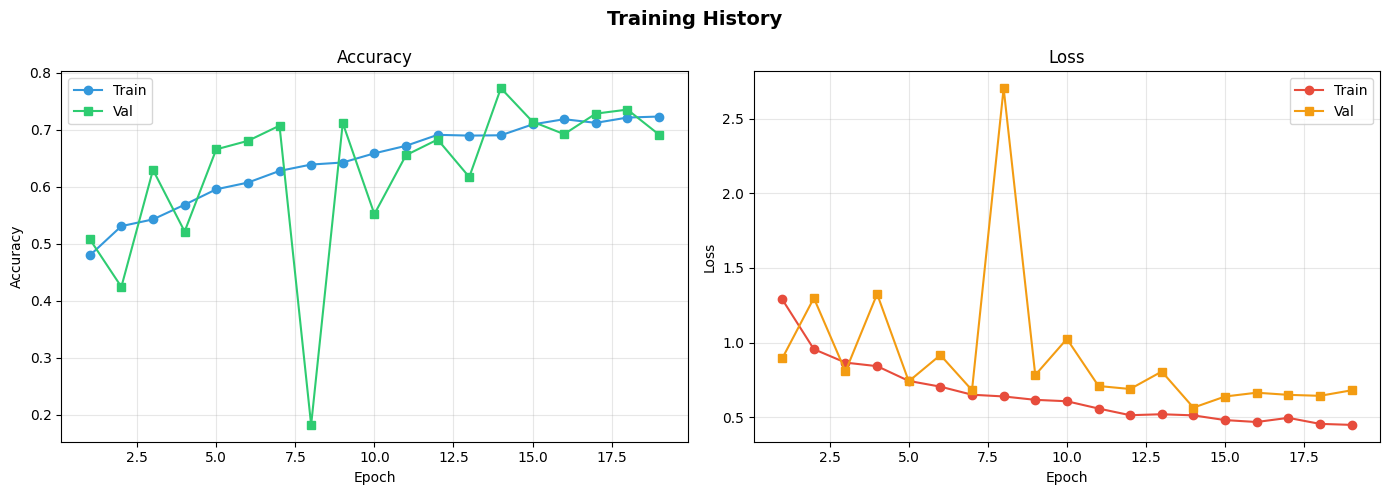

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],     'o-', color='#3498db', label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 's-', color='#2ecc71', label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['loss'],     'o-', color='#e74c3c', label='Train')
axes[1].plot(ep, history.history['val_loss'], 's-', color='#f39c12', label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"{'='*40}")


  Test Loss    : 0.5570
  Test Accuracy: 75.71%


In [ ]:
# ── Predictions
y_pred_prob   = model.predict(test_ds, verbose=0)
y_pred_labels = np.argmax(y_pred_prob, axis=1)
y_true_labels = np.array(test_labels)    # only integers, already in memory

print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=CLASS_NAMES, digits=4))


Classification Report:
              precision    recall  f1-score   support

      Normal     0.7570    0.7618    0.7594       319
        Mild     0.7564    0.7516    0.7540       314
 Alzheimer's     0.8000    0.8000    0.8000         5

    accuracy                         0.7571       638
   macro avg     0.7711    0.7711    0.7711       638
weighted avg     0.7571    0.7571    0.7570       638



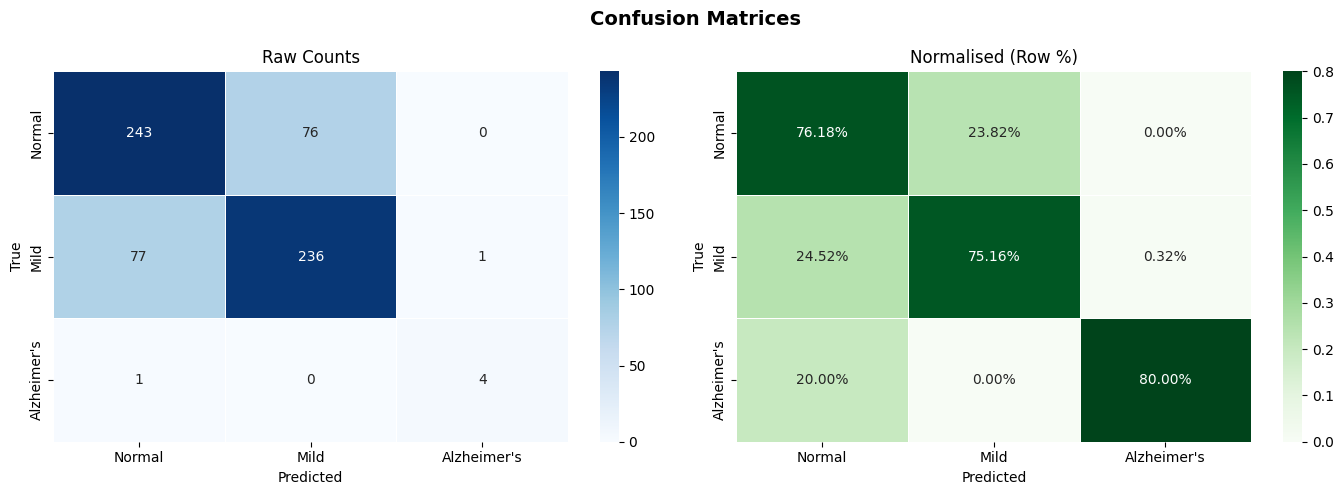

In [ ]:
# Confusion matrices
cm = confusion_matrix(y_true_labels, y_pred_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Normalised (Row %)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

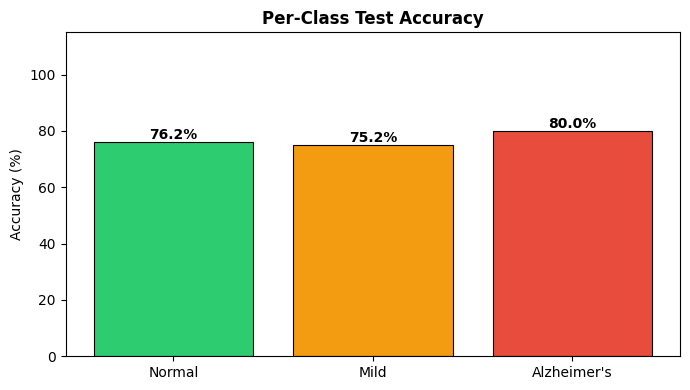

In [ ]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy', fontweight='bold')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Prediction Visualisation on Test Samples

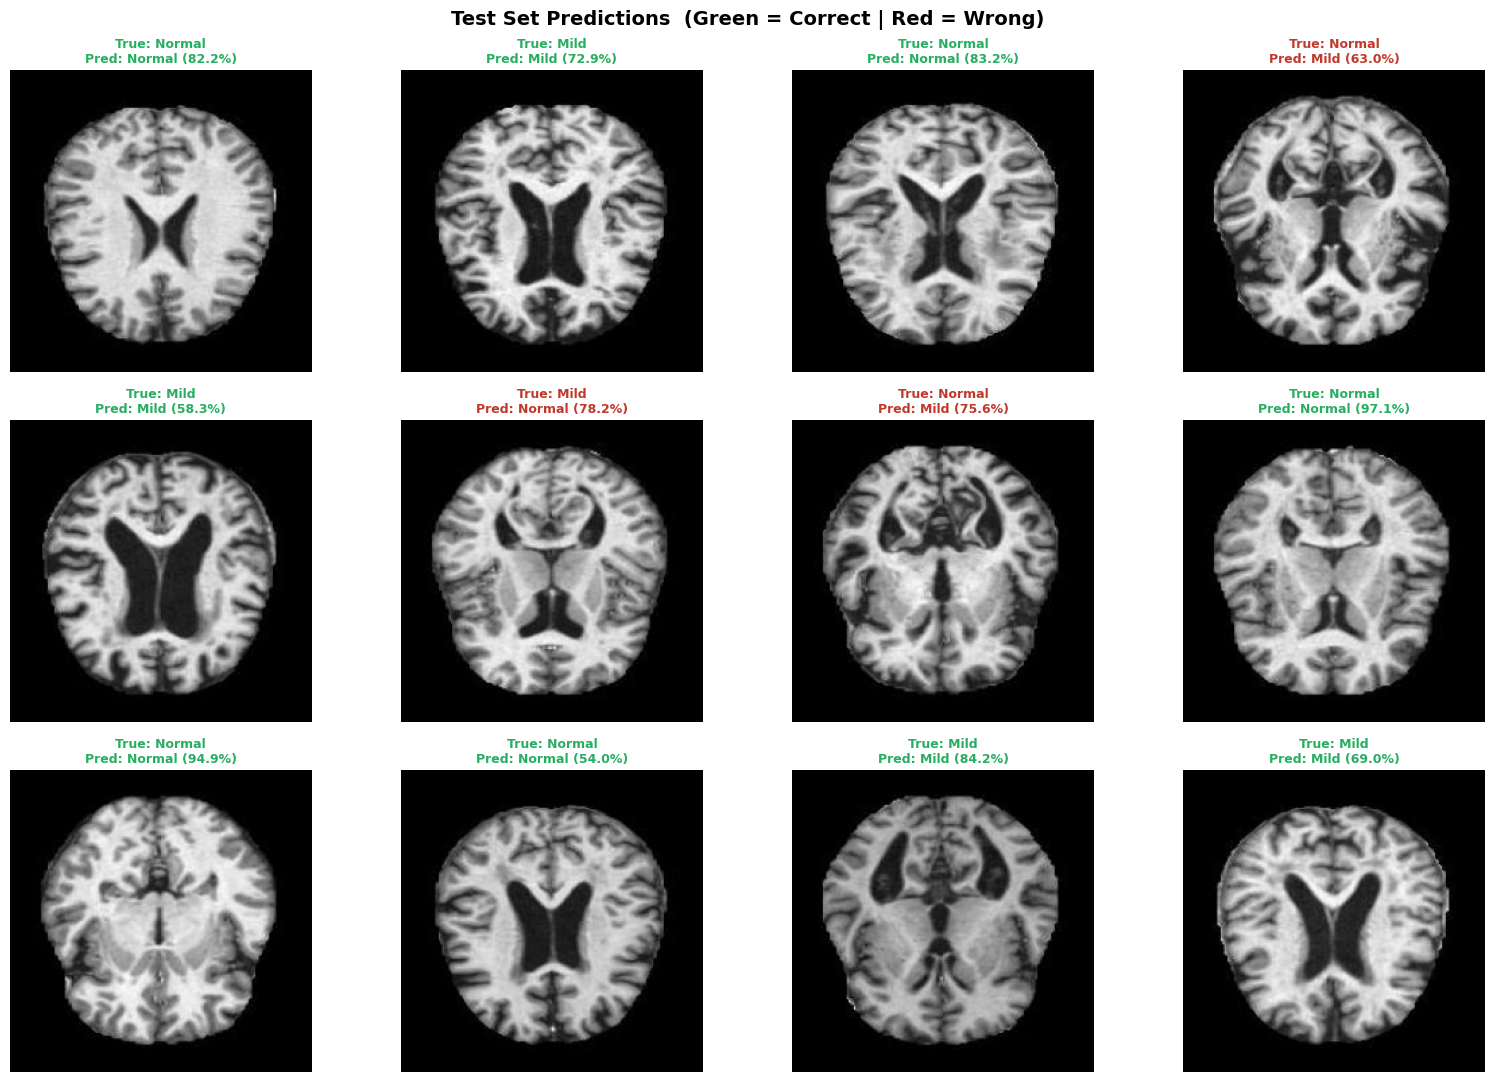

In [ ]:
# Load only 12 test images for display (not the whole test set)
n_show  = 12
indices = np.random.choice(len(test_paths), n_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Test Set Predictions  (Green = Correct | Red = Wrong)',
             fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), indices):
    img = cv2.imread(test_paths[idx])
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_cls = CLASS_NAMES[y_true_labels[idx]]
    pred_cls = CLASS_NAMES[y_pred_labels[idx]]
    conf     = y_pred_prob[idx, y_pred_labels[idx]] * 100
    correct  = y_true_labels[idx] == y_pred_labels[idx]
    color    = '#27ae60' if correct else '#c0392b'

    ax.imshow(img)
    ax.set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.show()

## Grad-CAM Explainability

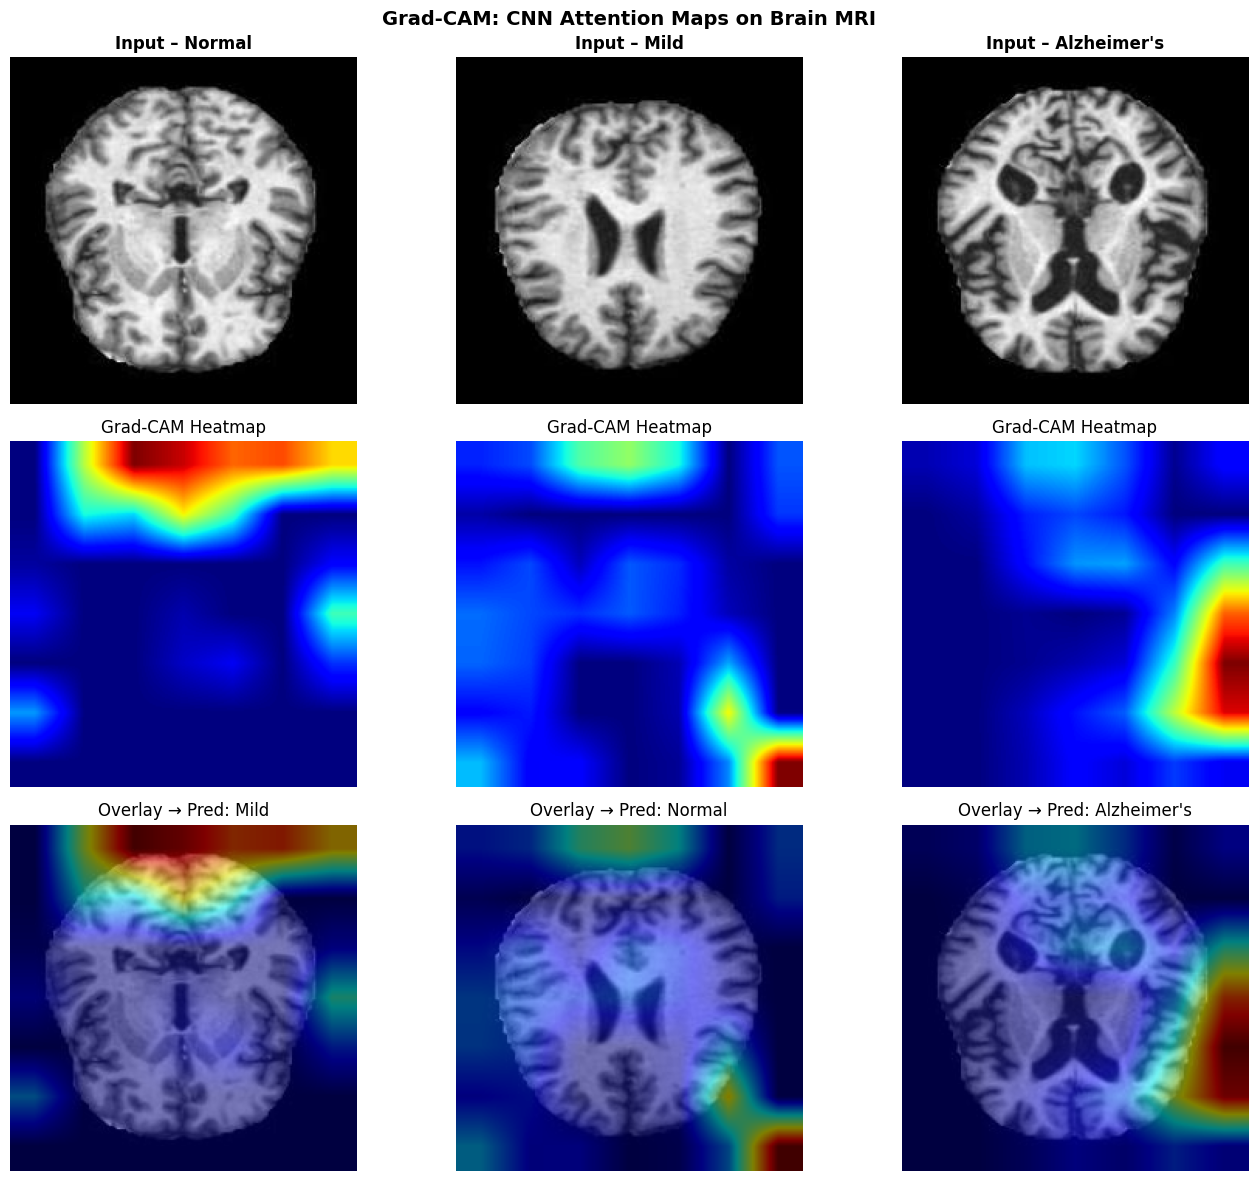

In [ ]:
def grad_cam(model, img_array, last_conv='conv5_block3_out'):
    """Generate Grad-CAM heatmap. img_array must be (224,224,3) float32 [0,1]."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv).output, model.output]
    )
    inp = tf.expand_dims(img_array, 0)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(inp, training=False)
        top_cls         = tf.argmax(preds[0])
        class_score     = preds[:, top_cls]
    grads   = tape.gradient(class_score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = (conv_out[0] @ pooled[..., tf.newaxis]).numpy().squeeze()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    return heatmap, int(top_cls)


# One sample per class
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Grad-CAM: CNN Attention Maps on Brain MRI',
             fontsize=14, fontweight='bold')

for col, cls_idx in enumerate([0, 1, 2]):
    candidates = [i for i, l in enumerate(test_labels) if l == cls_idx]
    if not candidates:
        continue
    idx = candidates[0]

    # Load single image (not the whole test set)
    raw_img = cv2.imread(test_paths[idx])
    raw_img = cv2.resize(raw_img, (IMG_SIZE, IMG_SIZE))
    disp    = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    img_f32 = disp.astype(np.float32) / 255.0

    hmap, pred_cls = grad_cam(model, img_f32)
    hmap_color = cv2.applyColorMap((hmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    hmap_color = cv2.cvtColor(hmap_color, cv2.COLOR_BGR2RGB)
    overlay    = cv2.addWeighted(disp, 0.5, hmap_color, 0.5, 0)

    axes[0, col].imshow(disp)
    axes[0, col].set_title(f'Input – {CLASS_NAMES[cls_idx]}', fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(hmap, cmap='jet')
    axes[1, col].set_title('Grad-CAM Heatmap')
    axes[1, col].axis('off')

    axes[2, col].imshow(overlay)
    axes[2, col].set_title(f'Overlay → Pred: {CLASS_NAMES[pred_cls]}')
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()

## Save Model

In [ ]:
save_path = base_path + "/alzheimer_cnn_model.h5"
model.save(save_path)
print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/Alzheimers_Detection_dataset/alzheimer_cnn_model.h5


## Final Summary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_labels, y_pred_labels, average='weighted')
recall    = recall_score(y_true_labels,    y_pred_labels, average='weighted')
f1        = f1_score(y_true_labels,        y_pred_labels, average='weighted')

print("\n" + "═"*46)
print("       ALZHEIMER'S DETECTION – RESULTS")
print("═"*46)
print(f"  Backbone       : ResNet50 (ImageNet weights)")
print(f"  Classes        : {CLASS_NAMES}")
print(f"  Image Size     : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Data Loading   : tf.data (memory-efficient)")
print("─"*46)
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print("─"*46)
print("  Per-class Accuracy:")
for cls, acc_val in zip(CLASS_NAMES, per_class_acc):
    print(f"    {cls:14s}: {acc_val*100:.2f}%")
print("═"*46)


══════════════════════════════════════════════
       ALZHEIMER'S DETECTION – RESULTS
══════════════════════════════════════════════
  Backbone       : ResNet50 (ImageNet weights)
  Classes        : ['Normal', 'Mild', "Alzheimer's"]
  Image Size     : 224×224
  Batch Size     : 32
  Data Loading   : tf.data (memory-efficient)
──────────────────────────────────────────────
  Test Accuracy  : 75.71%
  Test Loss      : 0.5570
  Precision      : 0.7571
  Recall         : 0.7571
  F1-Score       : 0.7570
──────────────────────────────────────────────
  Per-class Accuracy:
    Normal        : 76.18%
    Mild          : 75.16%
    Alzheimer's   : 80.00%
══════════════════════════════════════════════
